In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier

loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)

SELECTED_CHANNELS = [
    "flex_1", "flex_2", "flex_3", "flex_4", "flex_5", # 5 Sensores de Flexão
    "ACCx", "ACCy", "ACCz",                           # 3 Eixos de Aceleração Linear
    "GYRx", "GYRy", "GYRz"                            # 3 Eixos de Velocidade Angular
]

LABEL_COL        = "label"
SUBJECT_COL      = "subject"
WINDOW_SIZE      = 50
STRIDE_TRAIN     = 50   
STRIDE_EVAL      = 25   
DELTA_THRESHOLD  = 0.002
N_CLASSES        = 40


DATA_DIR = "/home/juan/Documentos/notebooks/ASL-Sensor-Dataglove-Dataset" 

np.random.seed(42)
tf.random.set_seed(42)

2026-06-01 19:14:23.666272: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-01 19:14:23.696449: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-01 19:14:23.829393: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-01 19:14:23.829420: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-01 19:14:23.854390: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

SELECTED_CHANNELS = [
    "flex_1", "flex_2", "flex_3", "flex_4", "flex_5",
    "ACCx", "ACCy", "ACCz",
    "GYRx", "GYRy", "GYRz"
]

LABEL_COL = "label"
SUBJECT_COL = "subject"
WINDOW_SIZE = 50
STRIDE = 25
DELTA_THRESHOLD = 0.02

def load_dataset(data_dir):
    frames = []
    for root, dirs, files in os.walk(data_dir):
        for fname in sorted(files):
            if fname.endswith(".csv"):
                file_path = os.path.join(root, fname)
                df = pd.read_csv(file_path)
                if LABEL_COL not in df.columns:
                    df[LABEL_COL] = fname.replace(".csv", "")
                if SUBJECT_COL not in df.columns:
                    df[SUBJECT_COL] = os.path.basename(root)
                df["source_file"] = fname
                frames.append(df)
    dataset = pd.concat(frames, ignore_index=True)
    dataset = dataset.dropna()
    return dataset

def split_by_subject(df, test_size=0.15, val_size=0.15, random_state=42):
    groups = df[SUBJECT_COL].values

    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    trainval_idx, test_idx = next(gss1.split(df, groups=groups))

    df_trainval = df.iloc[trainval_idx].reset_index(drop=True)
    df_test = df.iloc[test_idx].reset_index(drop=True)

    groups_trainval = df_trainval[SUBJECT_COL].values
    rel_val = val_size / (1.0 - test_size)

    gss2 = GroupShuffleSplit(n_splits=1, test_size=rel_val, random_state=random_state)
    train_idx, val_idx = next(gss2.split(df_trainval, groups=groups_trainval))

    df_train = df_trainval.iloc[train_idx].reset_index(drop=True)
    df_val = df_trainval.iloc[val_idx].reset_index(drop=True)

    return df_train, df_val, df_test


def extract_windows(df, channels, window_size=WINDOW_SIZE, stride=STRIDE, label_map=None):
    X_windows, y_windows = [], []

    for _, subj_df in df.groupby(SUBJECT_COL):
        values = subj_df[channels].values
        labels = subj_df[LABEL_COL].values

        for start in range(0, len(values) - window_size + 1, stride):
            end = start + window_size
            window_labels = labels[start:end]

            if len(np.unique(window_labels)) == 1:
                X_windows.append(values[start:end])
                y_windows.append(window_labels[0])

    X = np.array(X_windows, dtype=np.float32)
    y_raw = np.array(y_windows)

    if label_map is None:
        unique_labels = sorted(np.unique(y_raw))
        label_map = {lbl: idx for idx, lbl in enumerate(unique_labels)}

    y = np.array([label_map[lbl] for lbl in y_raw], dtype=np.int32)
    return X, y, label_map

def fit_normalizer(train_df, channels):
    scaler = StandardScaler()
    train_df = train_df.copy()
    train_df[channels] = scaler.fit_transform(train_df[channels])
    return scaler, train_df

def apply_normalizer(df, scaler, channels):
    df = df.copy()
    df[channels] = scaler.transform(df[channels])
    return df

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

def aplicar_normalizacao_hibrida(df, coluna_sujeito='subject'):

    colunas_flex = ['flex_1', 'flex_2', 'flex_3', 'flex_4', 'flex_5']
    colunas_imu = ['ACCx', 'ACCy', 'ACCz', 'GYRx', 'GYRy', 'GYRz']
    
    # Cria uma cópia do dataframe para não alterar o original diretamente
    df_norm = df.copy()
    
    # Lista de todos os participantes no dataframe
    sujeitos = df[coluna_sujeito].unique()
    
    print(f"Iniciando normalização híbrida para {len(sujeitos)} sujeitos...")
    
    for sujeito in sujeitos:
        # Pega apenas os índices (linhas) que pertencem a este sujeito
        idx = df[coluna_sujeito] == sujeito
        
        # Instancia scalers NOVOS para cada participante
        scaler_flex = MinMaxScaler()
        scaler_imu = StandardScaler()
        
        # Aplica MinMax aos sensores de flexão deste sujeito
        df_norm.loc[idx, colunas_flex] = scaler_flex.fit_transform(df.loc[idx, colunas_flex])
        
        # Aplica StandardScaler à IMU deste sujeito
        df_norm.loc[idx, colunas_imu] = scaler_imu.fit_transform(df.loc[idx, colunas_imu])
        
    print("Normalização concluída com sucesso!")
    return df_norm

In [4]:
# 1. Carrega os dados brutos 
print("Carregando dataset...")
df_raw = load_dataset(DATA_DIR)

# 2. APLICA A NORMALIZAÇÃO HÍBRIDA 
print("Aplicando normalização híbrida por sujeito...")
df_normalizado = aplicar_normalizacao_hibrida(df_raw, coluna_sujeito='subject')

# 3. Faz a divisão de treino/validação/teste 
print("Realizando particionamento LOSO...")
df_train, df_val, df_test = split_by_subject(df_normalizado)

# 4. Extrai as janelas 
print("Extraindo janelas temporais...")
X_train, y_train, label_map = extract_windows(df_train, SELECTED_CHANNELS, stride=STRIDE_TRAIN)
X_val,   y_val,   _         = extract_windows(df_val,   SELECTED_CHANNELS, stride=STRIDE_EVAL,  label_map=label_map)
X_test,  y_test,  _         = extract_windows(df_test,  SELECTED_CHANNELS, stride=STRIDE_EVAL,  label_map=label_map)

print(f"Formato final Treino: {X_train.shape}")

Carregando dataset...
Aplicando normalização híbrida por sujeito...
Iniciando normalização híbrida para 25 sujeitos...
Normalização concluída com sucesso!
Realizando particionamento LOSO...
Extraindo janelas temporais...
Formato final Treino: (20400, 50, 11)


In [5]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, GaussianNoise, BatchNormalization, Conv1D, MaxPooling1D, GlobalAveragePooling1D, Flatten
from tensorflow.keras.optimizers import Adam

def build_mlp_model(timesteps, n_features, n_classes):
    inputs = keras.Input(shape=(timesteps, n_features))
    x = layers.Flatten()(inputs)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="MLP")

def build_cnn1d_model(timesteps, n_features, n_classes):
    inputs = keras.Input(shape=(timesteps, n_features))
    
    x = GaussianNoise(0.01)(inputs)
    
    x = Conv1D(64, 5, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    x = Dropout(0.4)(x)

    x = Conv1D(128, 3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.5)(x) 

    x = Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x)
    outputs = Dense(n_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="CNN1D")
    
def build_lstm_model(timesteps, n_features, n_classes):
    inputs = keras.Input(shape=(timesteps, n_features))
    x = layers.LSTM(64, return_sequences=True)(inputs)
    x = layers.Dropout(0.4)(x)
    x = layers.LSTM(32)(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="LSTM")

def build_gru_model(timesteps, features, num_classes):
    model = Sequential([
        Input(shape=(timesteps, features)),
        GaussianNoise(0.01), 
        GRU(64, return_sequences=False, dropout=0.4, recurrent_dropout=0.2),
        Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import keras
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

TAMANHO_LOTE = 64

def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test, label_names, model_name):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    callbacks_list = [
        EarlyStopping(
            monitor='val_loss', 
            patience=7, 
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', 
            factor=0.5, 
            patience=3,  
            min_lr=1e-5,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f"best_{model_name}.keras",
            monitor="val_loss",
            save_best_only=True,
            mode="min",
            verbose=1
        )
    ]

    # 1. Calcula o peso de cada classe com base nos dados de treino
    pesos_array = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    # 2. Converte para um dicionário que o Keras entende
    pesos_dit = dict(enumerate(pesos_array))

    # 3. Passa para o modelo 
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=50,
        batch_size=32,
        class_weight=pesos_dit, 
        callbacks=callbacks_list, 
        verbose=1
    )

    y_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc = np.mean(y_pred == y_test)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1w = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    f1m = f1_score(y_test, y_pred, average="macro", zero_division=0)

    report = classification_report(y_test, y_pred, target_names=label_names, zero_division=0, output_dict=True)
    cm = confusion_matrix(y_test, y_pred, normalize="true")

    results = {
        "model": model_name,
        "accuracy": acc,
        "precision_weighted": prec,
        "recall_weighted": rec,
        "f1_weighted": f1w,
        "f1_macro": f1m,
        "history": history.history,
        "report": report,
        "cm": cm
    }
    return results

In [7]:
label_names = [k for k, v in sorted(label_map.items(), key=lambda x: x[1])]

models = {
    "mlp": build_mlp_model(X_train.shape[1], X_train.shape[2], N_CLASSES),
    "cnn1d": build_cnn1d_model(X_train.shape[1], X_train.shape[2], N_CLASSES),
    "lstm": build_lstm_model(X_train.shape[1], X_train.shape[2], N_CLASSES),
    "gru": build_gru_model(X_train.shape[1], X_train.shape[2], N_CLASSES),
}

results = {}

for name, model in models.items():
    print(f"\n=== Treinando {name.upper()} ===")
    results[name] = evaluate_model(
        model, X_train, y_train, X_val, y_val, X_test, y_test, label_names, name
    )

2026-06-01 19:14:49.417974: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-06-01 19:14:49.419669: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...



=== Treinando MLP ===
Epoch 1/50
605/638 [===========================>..] - ETA: 0s - loss: 1.8455 - accuracy: 0.4406
Epoch 1: val_loss improved from inf to 0.75654, saving model to best_mlp.keras
638/638 [==============================] - 2s 2ms/step - loss: 1.8076 - accuracy: 0.4505 - val_loss: 0.7565 - val_accuracy: 0.7391 - lr: 0.0010
Epoch 2/50
619/638 [============================>.] - ETA: 0s - loss: 0.9890 - accuracy: 0.6626
Epoch 2: val_loss improved from 0.75654 to 0.62298, saving model to best_mlp.keras
638/638 [==============================] - 1s 2ms/step - loss: 0.9859 - accuracy: 0.6637 - val_loss: 0.6230 - val_accuracy: 0.7898 - lr: 0.0010
Epoch 3/50
636/638 [============================>.] - ETA: 0s - loss: 0.8397 - accuracy: 0.7155
Epoch 3: val_loss improved from 0.62298 to 0.56350, saving model to best_mlp.keras
638/638 [==============================] - 1s 2ms/step - loss: 0.8397 - accuracy: 0.7154 - val_loss: 0.5635 - val_accuracy: 0.8121 - lr: 0.0010
Epoch 4/50
6

In [8]:
def plot_histories(results):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    for ax, (name, res) in zip(axes, results.items()):
        h = res["history"]
        ax.plot(h["loss"], label="Treino")
        ax.plot(h["val_loss"], label="Validação")
        ax.set_title(f"Loss - {name.upper()}")
        ax.set_xlabel("Época")
        ax.set_ylabel("Loss")
        ax.legend()

    plt.tight_layout()
    plt.show()

def plot_cm_grid(results, label_names, ncols=2):
    n = len(results)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 7*nrows))
    axes = np.array(axes).ravel()

    for ax, (name, res) in zip(axes, results.items()):
        sns.heatmap(res["cm"], ax=ax, cmap="Blues", vmin=0, vmax=1, cbar=False)
        ax.set_title(f"Matriz de Confusão - {name.upper()}")
        ax.set_xlabel("Predita")
        ax.set_ylabel("Real")

    for ax in axes[len(results):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [9]:
summary = []
for name, res in results.items():
    summary.append({
        "modelo": name.upper(),
        "acc": res["accuracy"],
        "prec_w": res["precision_weighted"],
        "rec_w": res["recall_weighted"],
        "f1_w": res["f1_weighted"],
        "f1_macro": res["f1_macro"],
    })

summary_df = pd.DataFrame(summary).sort_values("f1_macro", ascending=False)
summary_df

,modelo,acc,prec_w,rec_w,f1_w,f1_macro
1,CNN1D,0.877860,0.887803,0.877860,0.877546,0.877546
0,MLP,0.838030,0.852045,0.838030,0.839266,0.839266
2,LSTM,0.835593,0.850516,0.835593,0.833801,0.833801
3,GRU,0.830614,0.847722,0.830614,0.832720,0.832720


In [10]:
def plot_f1_compare(f1_by_model, label_names):
    n_models = len(f1_by_model)
    fig, axes = plt.subplots(n_models, 1, figsize=(18, 5 * n_models), sharex=True)

    if n_models == 1:
        axes = [axes]

    for ax, (model_name, f1_values) in zip(axes, f1_by_model.items()):
        order = np.argsort(f1_values)
        f1_sorted = f1_values[order]
        labels_sorted = [label_names[i] for i in order]

        ax.bar(range(len(f1_sorted)), f1_sorted, color=sns.color_palette("viridis", len(f1_sorted)))
        ax.axhline(np.mean(f1_sorted), ls="--", color="red", label=f"Média: {np.mean(f1_sorted):.3f}")
        ax.set_title(f"F1-score por classe — {model_name}")
        ax.set_ylabel("F1-score")
        ax.set_ylim(0, 1.05)
        ax.legend()

        ax.set_xticks(range(len(f1_sorted)))
        ax.set_xticklabels(labels_sorted, rotation=90)

    plt.xlabel("Classe")
    plt.tight_layout()
    plt.show()

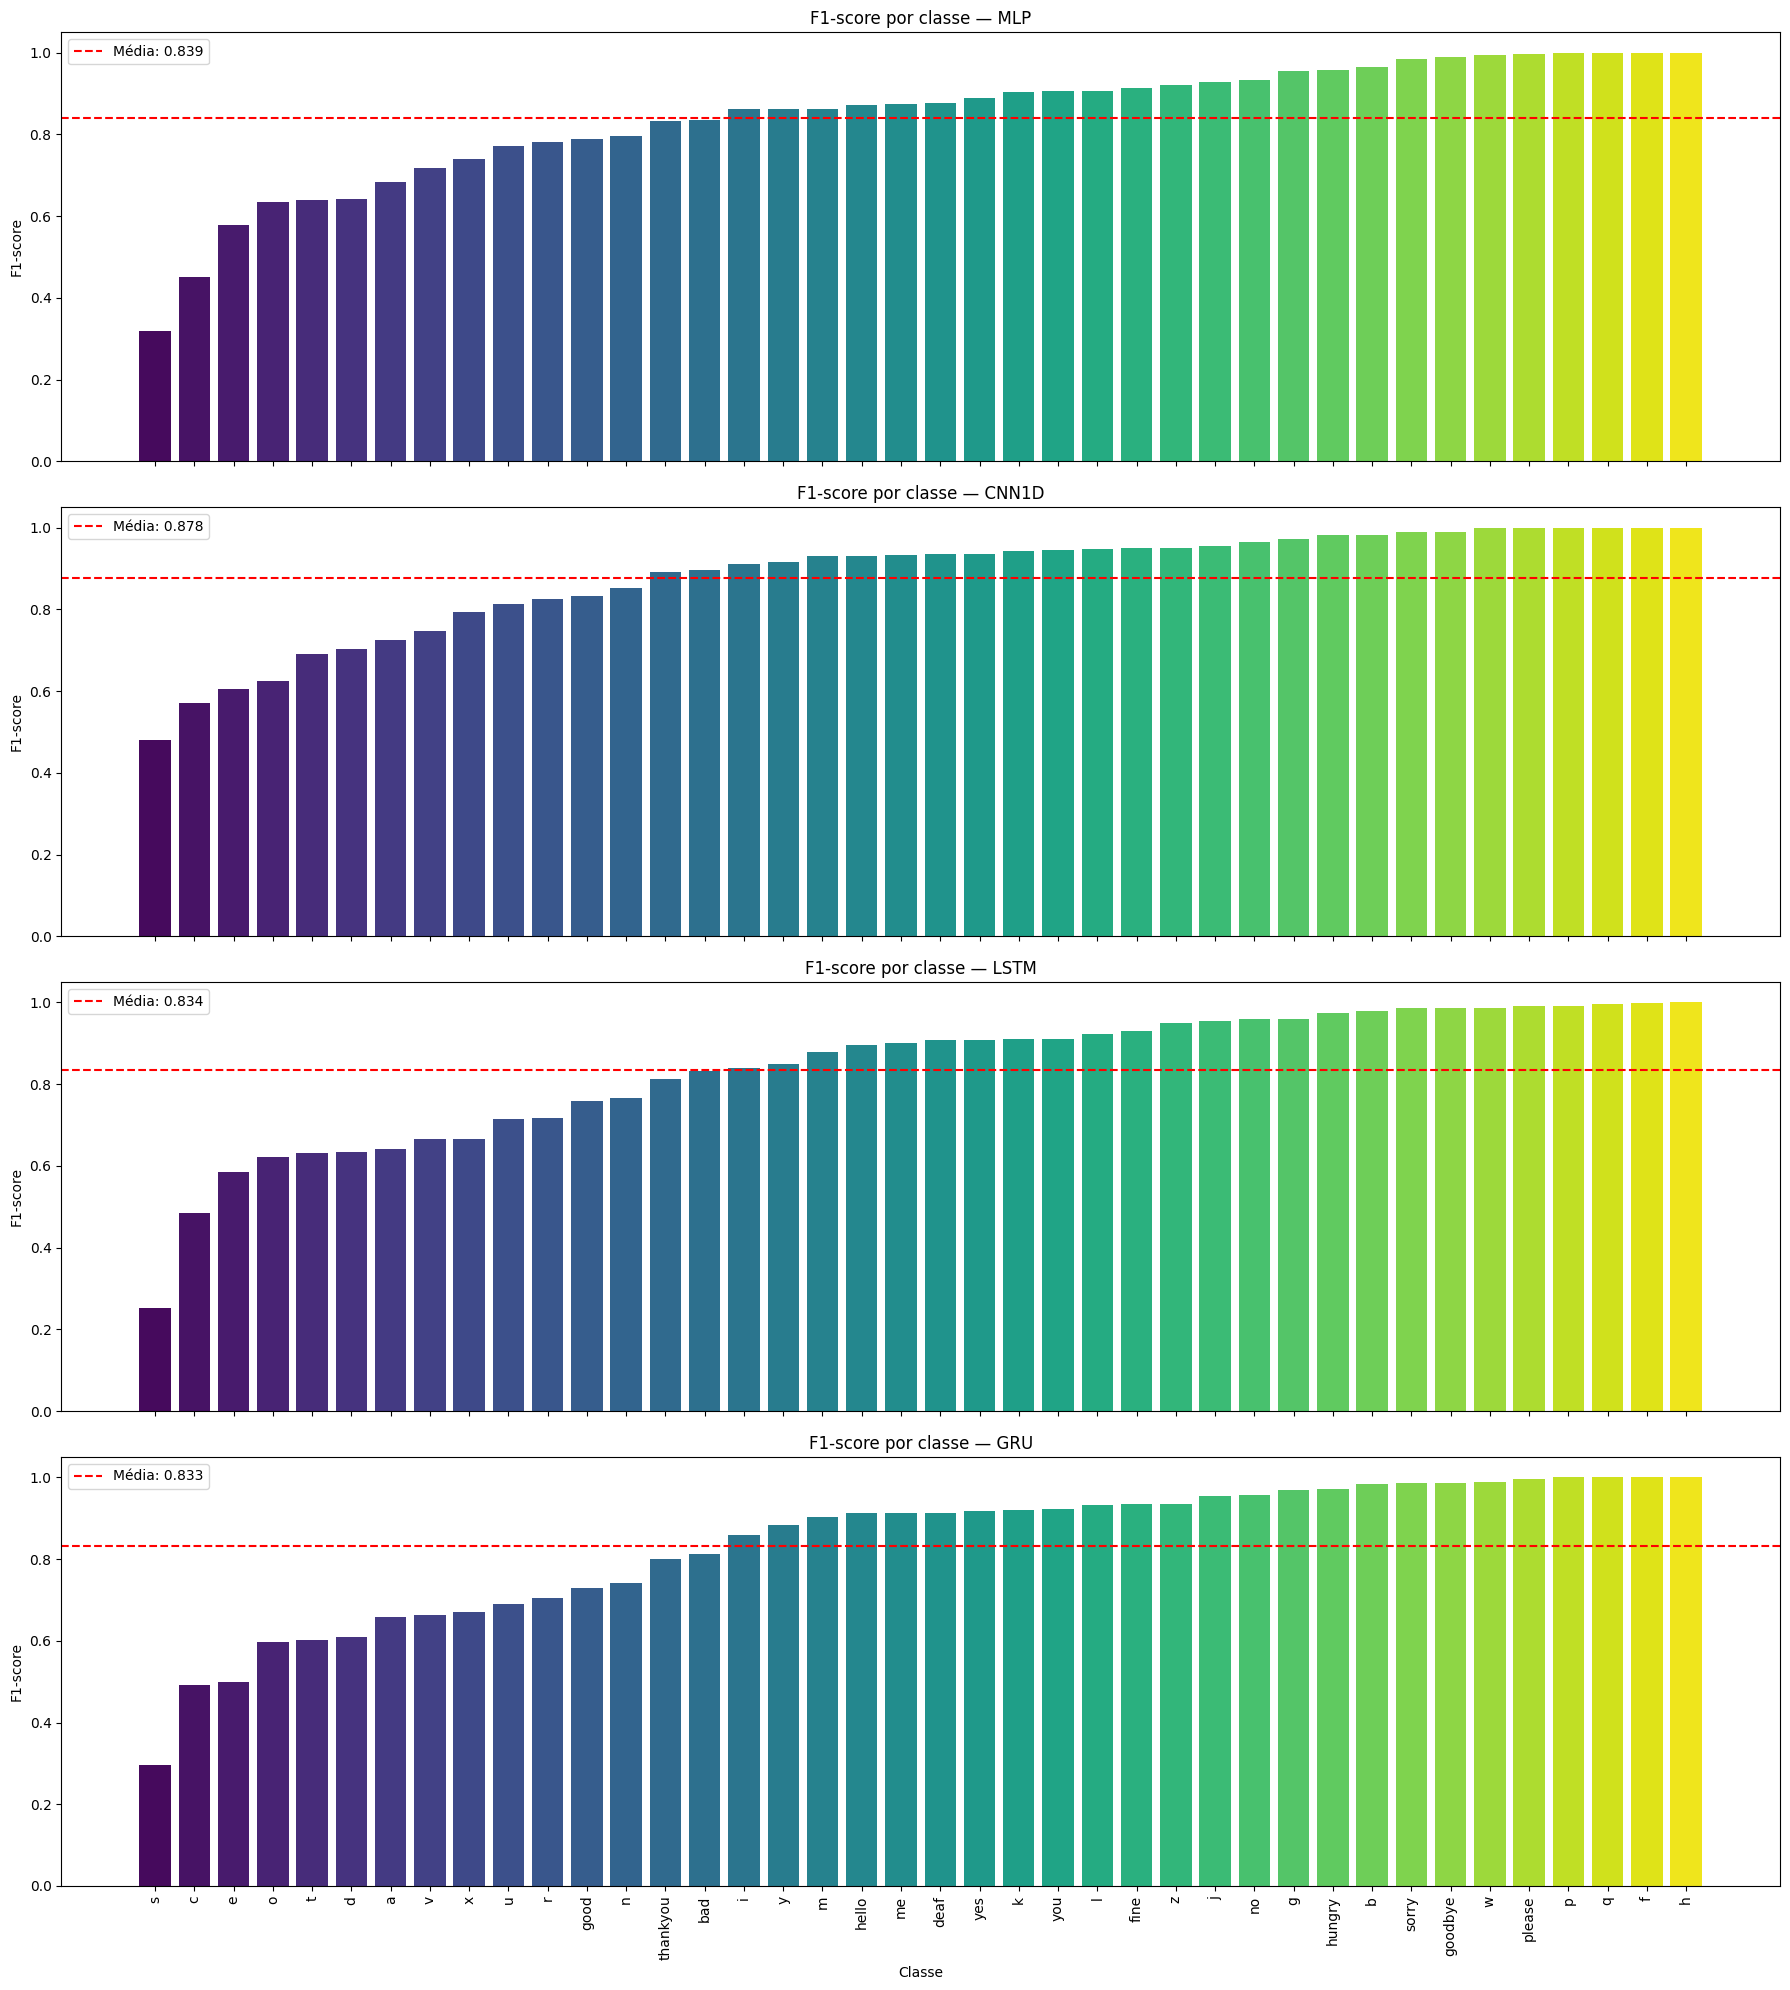

In [11]:
f1_by_model = {}

for name, res in results.items():
    f1_values = np.array([res["report"][cls]["f1-score"] for cls in label_names])
    f1_by_model[name.upper()] = f1_values

plot_f1_compare(f1_by_model, label_names)

In [12]:
def analisar_maiores_erros(cm, label_names, top_n=5):
    """Identifica os pares de gestos mais confundidos pelo modelo."""
    cm_errors = cm.copy()
    np.fill_diagonal(cm_errors, 0)
    
    # Obter os índices das maiores taxas de confusão
    indices = np.argsort(cm_errors, axis=None)[::-1]
    
    print(f"--- Top {top_n} Maiores Confusões ---")
    vistos = set()
    count = 0
    for idx in indices:
        if count >= top_n:
            break
        i, j = np.unravel_index(idx, cm_errors.shape)
        if cm_errors[i, j] > 0 and (i, j) not in vistos:
            print(f"Gesto Real: '{label_names[i]:<15}' confundido com '{label_names[j]:<15}' ({cm_errors[i, j]:.1%} das amostras reais)")
            vistos.add((i, j))
            count += 1


melhor_modelo_nome = "gru"
print(f"\nAnálise de Erros para o modelo {melhor_modelo_nome.upper()}:")
analisar_maiores_erros(results[melhor_modelo_nome]["cm"], label_names, top_n=5)


Análise de Erros para o modelo GRU:
--- Top 5 Maiores Confusões ---
Gesto Real: 's              ' confundido com 'e              ' (52.5% das amostras reais)
Gesto Real: 'd              ' confundido com 't              ' (50.0% das amostras reais)
Gesto Real: 'e              ' confundido com 's              ' (40.7% das amostras reais)
Gesto Real: 'n              ' confundido com 'r              ' (36.0% das amostras reais)
Gesto Real: 'v              ' confundido com 'u              ' (30.1% das amostras reais)


In [13]:
print("\n=== Análise de Tamanho e Memória dos Modelos (Foco em TinyML) ===")
for name, model in models.items():
    # Conta o número total de parâmetros treináveis
    trainable_params = np.sum([np.prod(v.get_shape()) for v in model.trainable_weights])
    
    # Estimativa de tamanho em SRAM (Peso Float32 padrão = 4 bytes por parâmetro)
    size_kb = (trainable_params * 4) / 1024
    
    # Estimativa de tamanho pós-quantização (INT8 = 1 byte por parâmetro)
    size_kb_quantizado = trainable_params / 1024
    
    print(f"Modelo: {name.upper():<7} | Parâmetros: {trainable_params:<7} | Estimativa Float32: {size_kb:>7.2f} KB | Quantizado (INT8): {size_kb_quantizado:>7.2f} KB")



=== Análise de Tamanho e Memória dos Modelos (Foco em TinyML) ===
Modelo: MLP     | Parâmetros: 184808  | Estimativa Float32:  721.91 KB | Quantizado (INT8):  180.48 KB
Modelo: CNN1D   | Parâmetros: 39528   | Estimativa Float32:  154.41 KB | Quantizado (INT8):   38.60 KB
Modelo: LSTM    | Parâmetros: 36584   | Estimativa Float32:  142.91 KB | Quantizado (INT8):   35.73 KB
Modelo: GRU     | Parâmetros: 21544   | Estimativa Float32:   84.16 KB | Quantizado (INT8):   21.04 KB


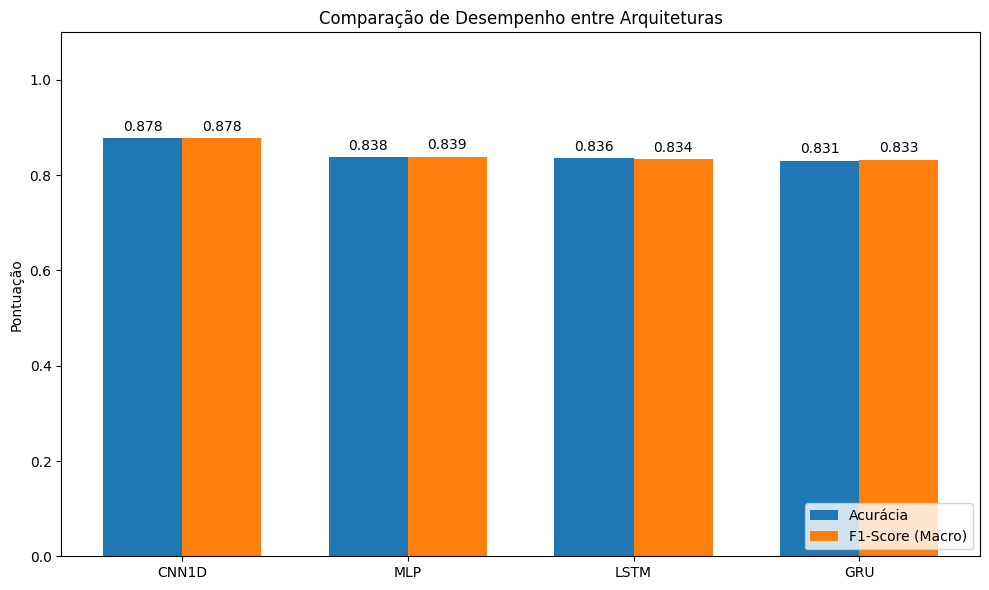

In [14]:
import matplotlib.pyplot as plt
import numpy as np


nomes_modelos = summary_df['modelo'].tolist()
acuracias = summary_df['acc'].tolist()
f1_macros = summary_df['f1_macro'].tolist()

x = np.arange(len(nomes_modelos))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Criando as barras
rects1 = ax.bar(x - width/2, acuracias, width, label='Acurácia', color='#1f77b4')
rects2 = ax.bar(x + width/2, f1_macros, width, label='F1-Score (Macro)', color='#ff7f0e')

ax.set_ylabel('Pontuação')
ax.set_title('Comparação de Desempenho entre Arquiteturas')
ax.set_xticks(x)
ax.set_xticklabels(nomes_modelos)
ax.set_ylim(0, 1.1) 
ax.legend(loc='lower right') 


ax.bar_label(rects1, padding=3, fmt='%.3f')
ax.bar_label(rects2, padding=3, fmt='%.3f')

fig.tight_layout()
plt.savefig('comparacao_modelos.png', dpi=300) 
plt.show()

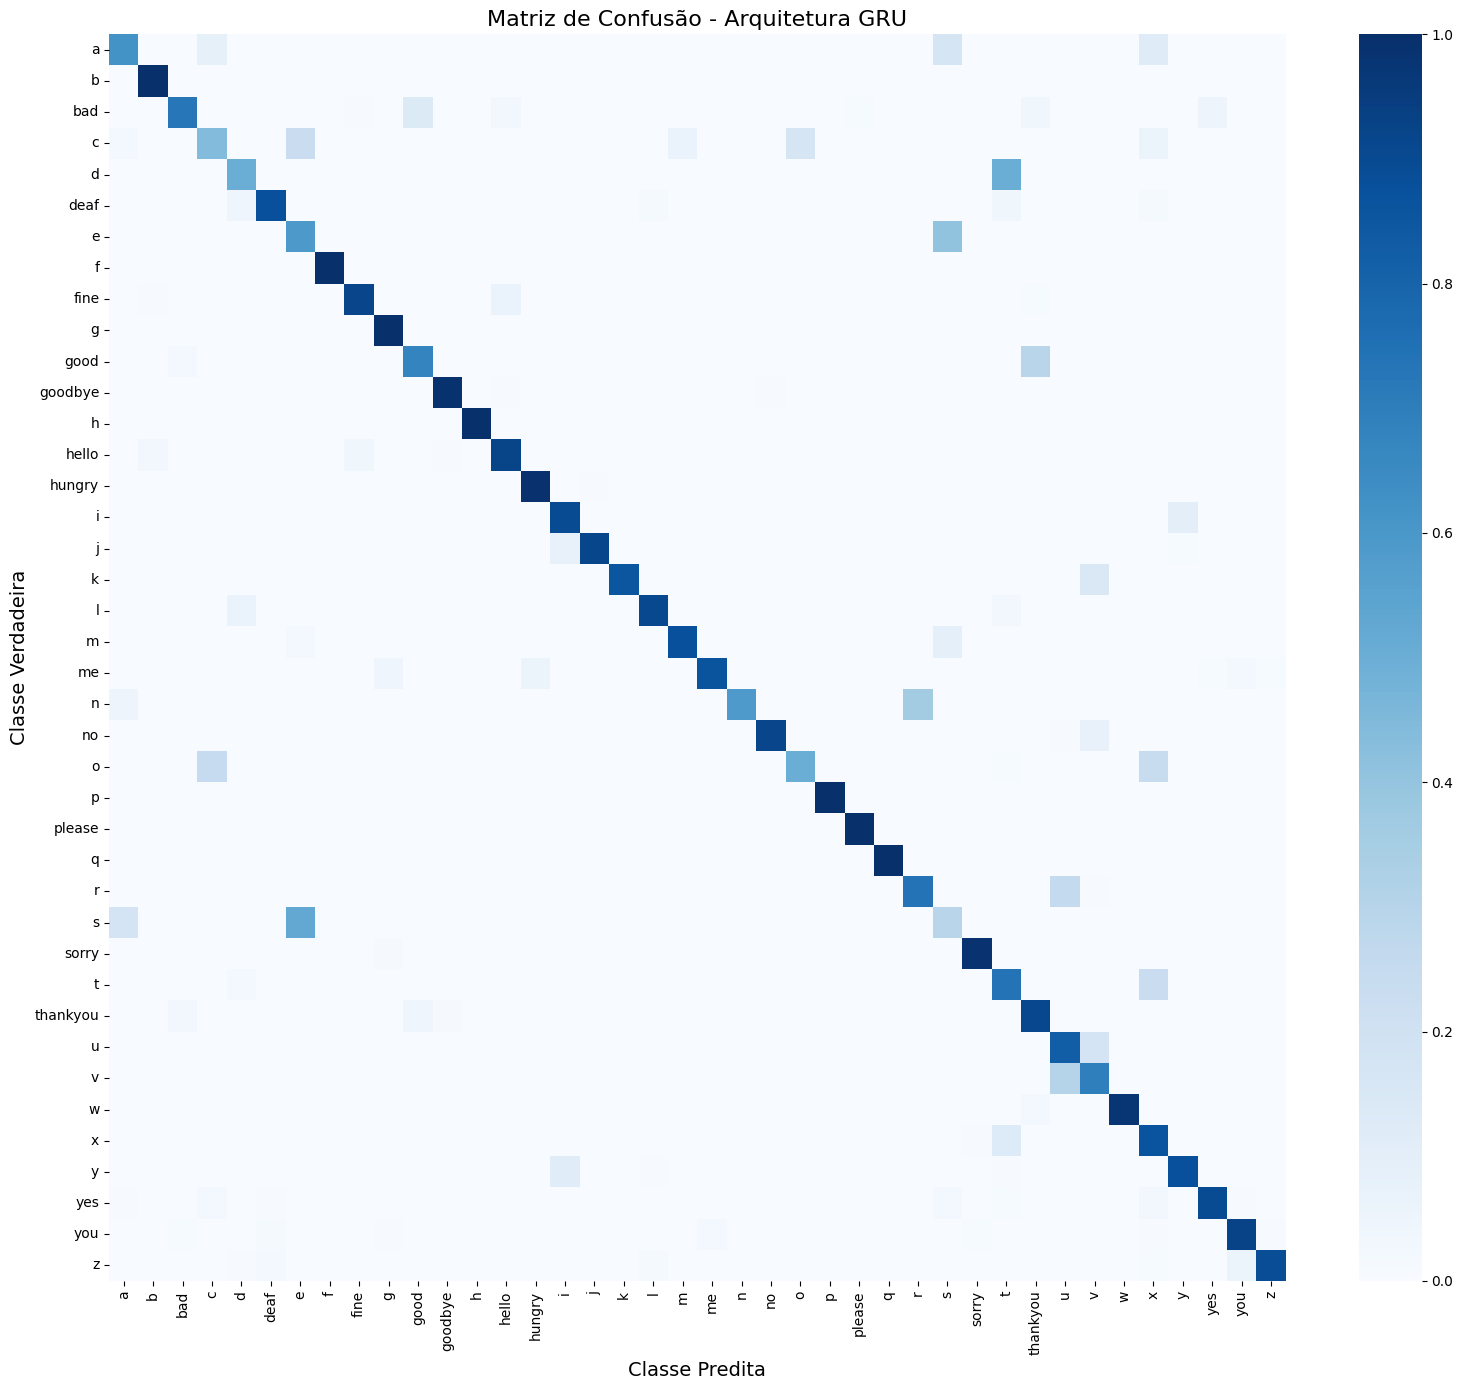

In [15]:
import seaborn as sns


cm_gru = results['gru']['cm'] 

plt.figure(figsize=(16, 14)) 


sns.heatmap(cm_gru, annot=False, cmap='Blues', 
            xticklabels=label_names, yticklabels=label_names)

plt.title('Matriz de Confusão - Arquitetura GRU', fontsize=16)
plt.ylabel('Classe Verdadeira', fontsize=14)
plt.xlabel('Classe Predita', fontsize=14)

# Rotacionar os labels do eixo X para facilitar a leitura
plt.xticks(rotation=90) 
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('matriz_confusao_gru.png', dpi=300) 
plt.show()

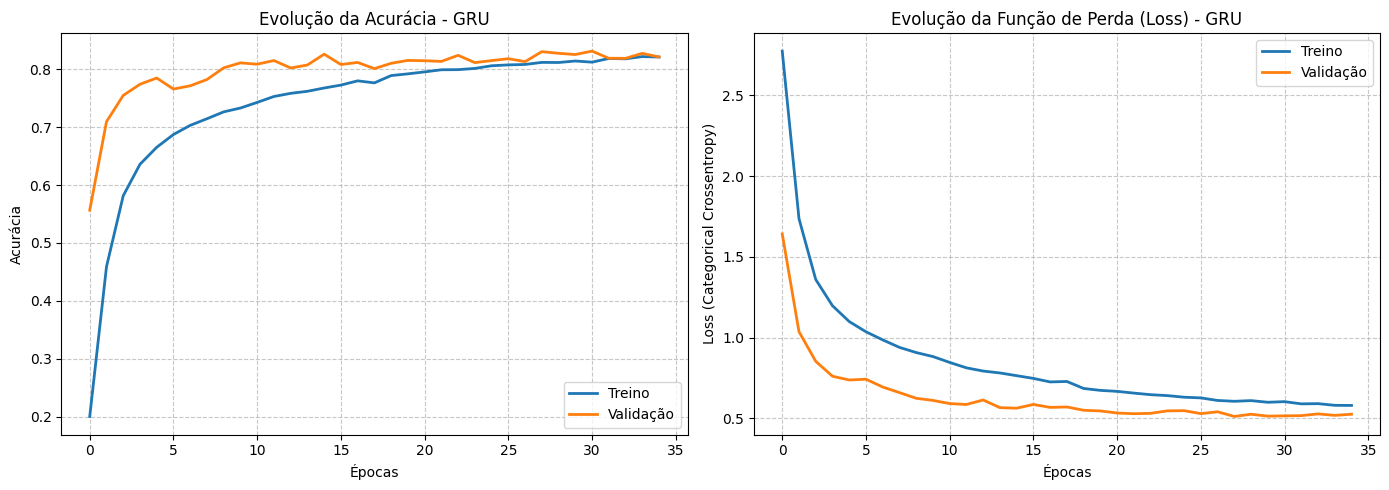

In [16]:
import matplotlib.pyplot as plt

# Acessando o histórico de treinamento do modelo GRU a partir do seu dicionário 'results'
historico = results['gru']['history']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Acurácia
ax1.plot(historico['accuracy'], label='Treino', linewidth=2)
ax1.plot(historico['val_accuracy'], label='Validação', linewidth=2)
ax1.set_title('Evolução da Acurácia - GRU')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Acurácia')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Gráfico de Perda (Loss)
ax2.plot(historico['loss'], label='Treino', linewidth=2)
ax2.plot(historico['val_loss'], label='Validação', linewidth=2)
ax2.set_title('Evolução da Função de Perda (Loss) - GRU')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Loss (Categorical Crossentropy)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('curvas_aprendizado_gru.png', dpi=300) # Salva para o Overleaf
plt.show()

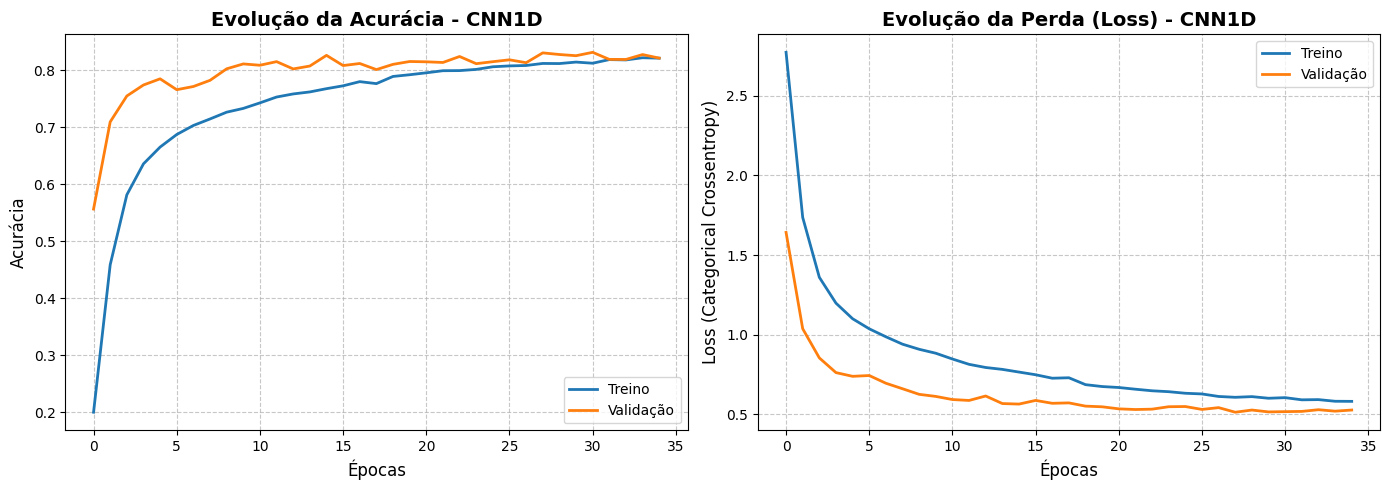

In [18]:
import matplotlib.pyplot as plt

# Cria a figura com dois gráficos lado a lado (1 linha, 2 colunas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------------------------------------
# Gráfico 1: Acurácia (CNN1D)
# ---------------------------------------------------
ax1.plot(historico['accuracy'], label='Treino', linewidth=2, color='#1f77b4')
ax1.plot(historico['val_accuracy'], label='Validação', linewidth=2, color='#ff7f0e')
ax1.set_title('Evolução da Acurácia - CNN1D', fontsize=14, fontweight='bold')
ax1.set_xlabel('Épocas', fontsize=12)
ax1.set_ylabel('Acurácia', fontsize=12)
ax1.legend(loc='lower right')
ax1.grid(True, linestyle='--', alpha=0.7)

# ---------------------------------------------------
# Gráfico 2: Perda / Loss (CNN1D)
# ---------------------------------------------------
ax2.plot(historico['loss'], label='Treino', linewidth=2, color='#1f77b4')
ax2.plot(historico['val_loss'], label='Validação', linewidth=2, color='#ff7f0e')
ax2.set_title('Evolução da Perda (Loss) - CNN1D', fontsize=14, fontweight='bold')
ax2.set_xlabel('Épocas', fontsize=12)
ax2.set_ylabel('Loss (Categorical Crossentropy)', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.7)

# Ajusta o espaçamento para não sobrepor textos
plt.tight_layout()

# Salva a imagem em alta resolução (ideal para o artigo/Overleaf)
plt.savefig('curvas_aprendizado_cnn1d.png', dpi=300, bbox_inches='tight') 

# Mostra o gráfico na tela
plt.show()

295/295 [==============================] - 1s 3ms/step


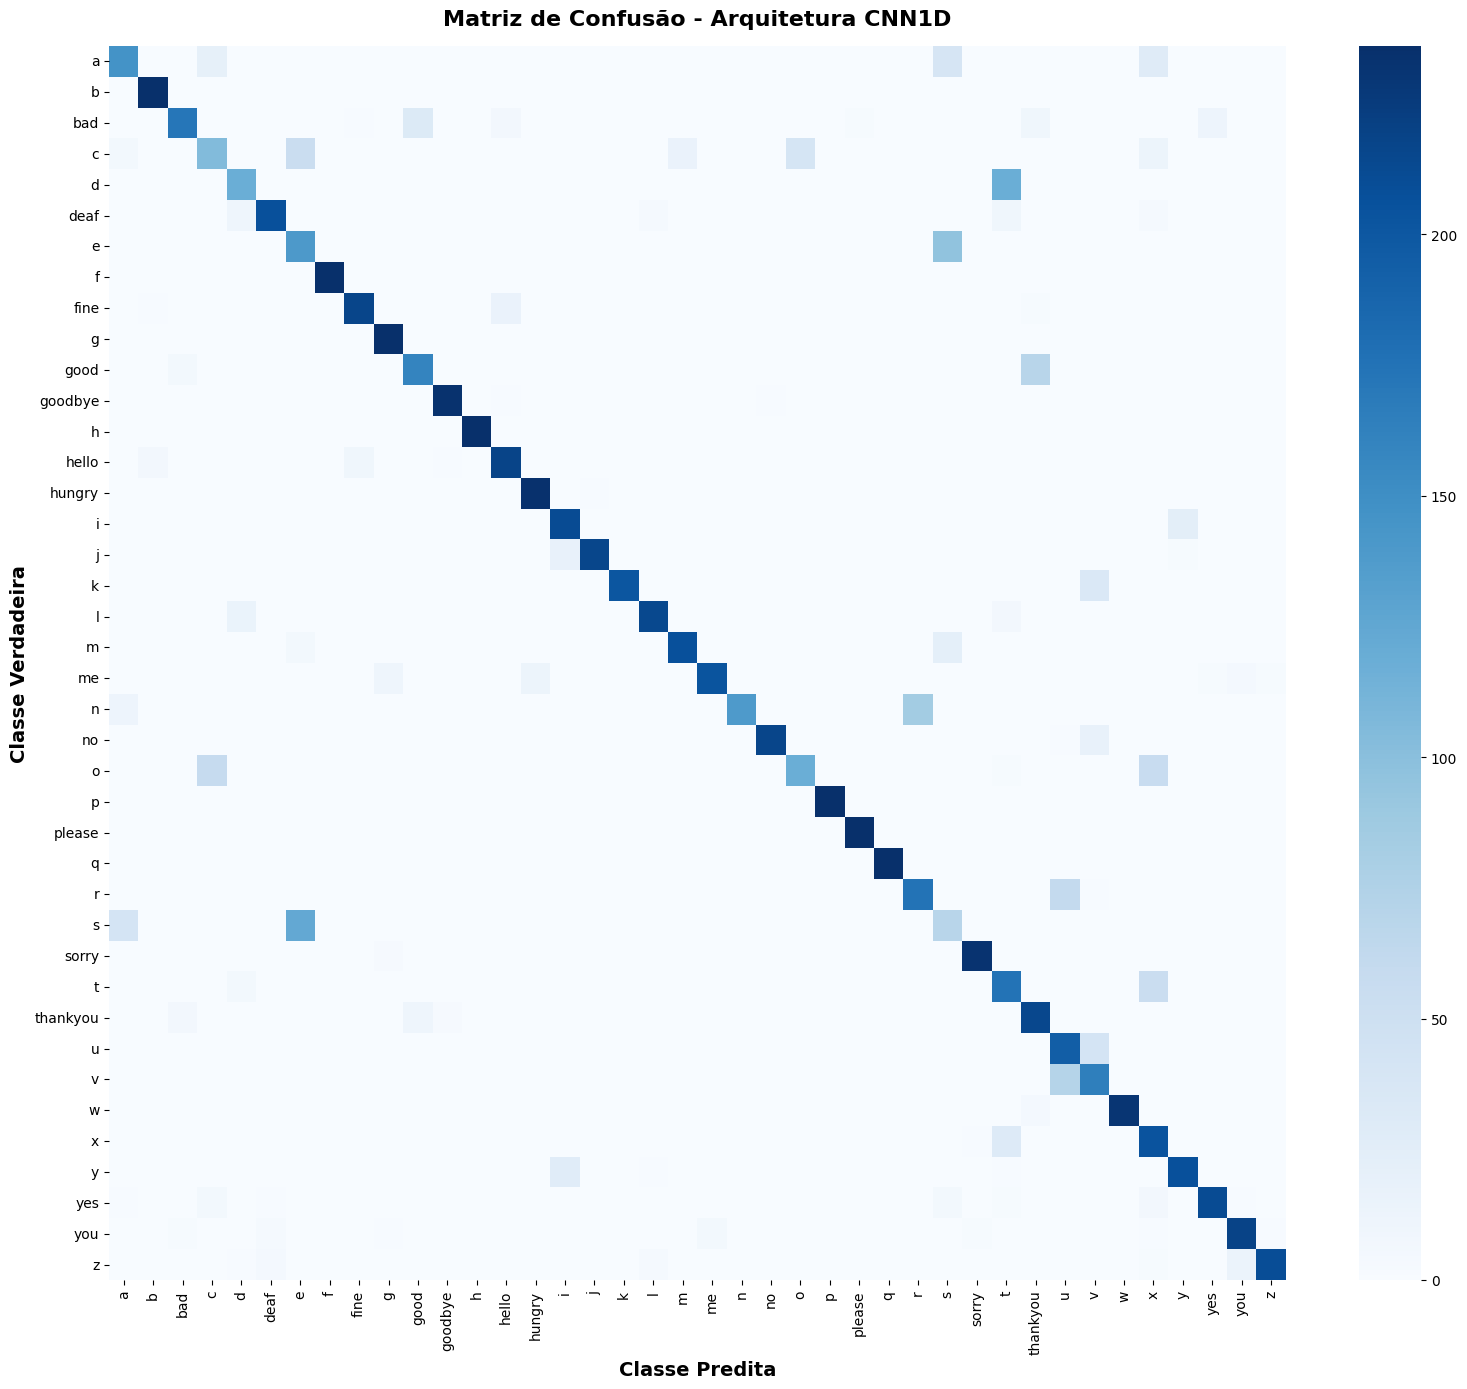

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =========================================================
# 1. FAZER AS PREVISÕES E CALCULAR A MATRIZ
# =========================================================
# (Assumindo que o seu modelo CNN treinado está na variável 'model')
y_pred_prob = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_prob, axis=1)

# Converte o y_test para classes se estiver em One-Hot
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_true_classes = np.argmax(y_test, axis=1)
else:
    y_true_classes = y_test

# Calcula a matriz
cm_cnn = confusion_matrix(y_true_classes, y_pred_classes)

# =========================================================
# 2. EXTRAIR OS NOMES DOS GESTOS
# =========================================================
# Pega o seu dicionário label_map (ex: {'A': 0, 'B': 1}) e transforma numa 
# lista ordenada de nomes para usar no gráfico
label_names = [k for k, v in sorted(label_map.items(), key=lambda item: item[1])]

# =========================================================
# 3. PLOTAR A MATRIZ DE CONFUSÃO (FORMATO ARTIGO)
# =========================================================
plt.figure(figsize=(16, 14)) 

# Criar o Heatmap (annot=False deixa mais limpo, usando label_names nos eixos)
sns.heatmap(cm_cnn, annot=False, cmap='Blues', 
            xticklabels=label_names, yticklabels=label_names)

plt.title('Matriz de Confusão - Arquitetura CNN1D', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Classe Verdadeira', fontsize=14, fontweight='bold')
plt.xlabel('Classe Predita', fontsize=14, fontweight='bold')

# Rotacionar os labels do eixo X para facilitar a leitura dos nomes dos gestos
plt.xticks(rotation=90, fontsize=10) 
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('matriz_confusao_cnn1d.png', dpi=300) 
plt.show()